In [1]:
import numpy as np
import numpy.typing as npt
import pandas as pd
import yaml
from matplotlib import pyplot as plt
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay

import import_ipynb
import preprocessing_data

Overwriting requirements.txt
Note: you may need to restart the kernel to use updated packages.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100514 entries, 0 to 100513
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Loan ID                       100000 non-null  object 
 1   Customer ID                   100000 non-null  object 
 2   Loan Status                   100000 non-null  object 
 3   Current Loan Amount           100000 non-null  float64
 4   Term                          100000 non-null  object 
 5   Credit Score                  80846 non-null   float64
 6   Annual Income                 80846 non-null   float64
 7   Years in current job          95778 non-null   object 
 8   Home Ownership                100000 non-null  object 
 9   Purpose                       100000 non-null  object 
 10  Monthly Debt                  100000 non-null  float64
 11  Years of 

<string>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


<string>:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform 

In [2]:
X_train = pd.read_csv("X_train_scaled.csv")
X_test  = pd.read_csv("X_test_scaled.csv")
y_train = pd.read_csv("y_train.csv")["Loan Status"]
y_test  = pd.read_csv("y_test.csv")["Loan Status"]

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

X_train: (71828, 26) X_test: (17957, 26)
y_train: (71828,) y_test: (17957,)


In [4]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
# Initialize the logistic regression model
model = RandomForestClassifier(
    n_estimators=200,    # number of trees
    max_depth=None,      # tree depth (None = grow fully)
    min_samples_split=2, # min samples to split a node
    random_state=16,
    class_weight='balanced' 
)
 

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=16)

In [5]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)  # probabilities in [0,1]      # choose your threshold

In [6]:
#Calculate accuracy
accuracy = metrics.accuracy_score(y_test, y_pred)
print(accuracy)

0.8027510163167567


In [7]:
#Calculate precision
precision = metrics.precision_score(y_test, y_pred)
print(precision)

0.7949758338803031


In [8]:
#Calculate recall
recall = metrics.recall_score(y_test,y_pred)
print(recall)

0.992106634894631


In [9]:
#Calculate average precision
average_precision = metrics.average_precision_score(y_test, y_pred)
print(average_precision)

0.7946037898507919


In [10]:
#Calculate F1 score
f1_score = metrics.f1_score(y_test, y_pred)
print(f1_score)

0.882668610043726


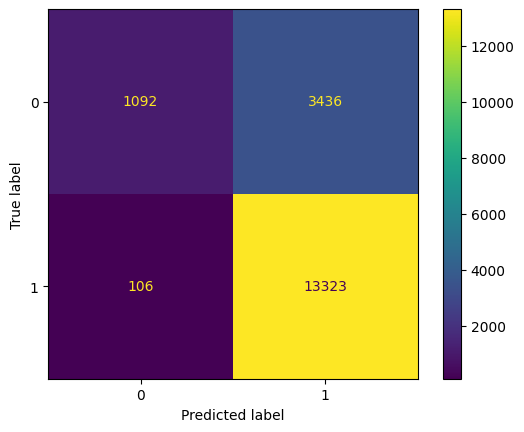

In [11]:
#Calculate specificity
conf_matrix = metrics.confusion_matrix(y_test, y_pred)
denom = conf_matrix[0][0]+conf_matrix[0][1]
if denom == 0:
    denom = 1
specificity = conf_matrix[0][0]/(denom)

#Visualize confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix,
                              display_labels=model.classes_)
disp.plot()
plt.show()

In [12]:
#Calculate ROC score
fpr, tpr, threshold = metrics.roc_curve(y_test, y_pred)


AUROC: 0.7701687362037802


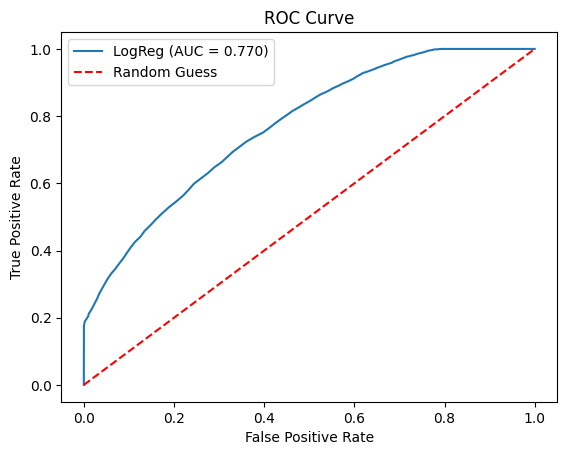

In [13]:
from sklearn.metrics import roc_auc_score, roc_curve

# Use y_prob, not y_pred, for AUROC
auroc = roc_auc_score(y_test, y_prob)
print("AUROC:", auroc)

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"LogReg (AUC = {auroc:.3f})")
plt.plot([0,1],[0,1],'r--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()